In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Rr_computation import compute_response_recovery # can be adapted to your own implementation
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates


In [2]:
# ------------------------------
# Load Data
# ------------------------------
SouthHolland_data = pd.read_pickle(r"C:\Users\mjg9941\Documents\PhD_Research\Projects\SmartWater\Python_Projects\ERL_HotMoment\SouthHolland_WaterQualityData_Sept25toJan26.pkl")

site_data = {
    'CottageGrove': SouthHolland_data, 
}

parameters= ["SPCOND µS/CM"] # More parameters can be evaluated by adding them to the list

### Step i: Define Temporal Scale of Analysis

In [3]:
windows = [pd.Timedelta("24h")] #Several time windows can be tested at once


### Step ii: Compute response and recovery for all observations in a given time series.

In [4]:

all_results = []

for site, df in site_data.items():
    for w in windows:
        res = compute_response_recovery(
            df,
            parameters,
            window_length=w,
            step=pd.Timedelta("5min"),
            max_change=0.15
        )

        res["site"] = site
        res["window_length"] = w
        all_results.append(res)

results = pd.concat(all_results, ignore_index=True)

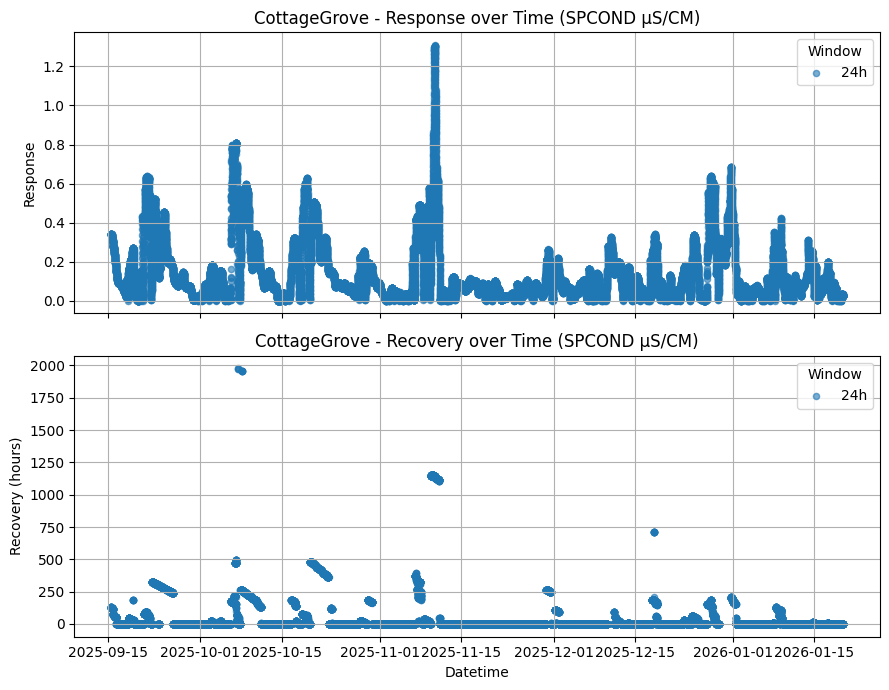

In [5]:
for site in results["site"].unique():
    
    df_site = results[results["site"] == site]
    
    if df_site.empty:
        print(f"No results for {site}, skipping plot.")
        continue

    for parameter in df_site["parameter"].unique():
        
        df_param = df_site[df_site["parameter"] == parameter]
        
        if df_param.empty:
            continue

        fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

        for w in sorted(df_param["window_length"].unique()):
            
            df_w = df_param[df_param["window_length"] == w]
            
            label = f"{int(w.total_seconds()/3600)}h"

            # --- Response ---
            axes[0].scatter(
                df_w["start_time"],
                df_w["response"],
                s=20,
                alpha=0.6,
                label=label
            )

            # --- Recovery ---
            recovery_hours = df_w["recovery"].dt.total_seconds() / 3600
            
            axes[1].scatter(
                df_w["start_time"],
                recovery_hours,
                s=20,
                alpha=0.6,
                label=label
            )

        axes[0].set_ylabel("Response")
        axes[0].set_title(f"{site} - Response over Time ({parameter})")
        axes[0].grid(True)
        axes[0].legend(title="Window")

        axes[1].set_ylabel("Recovery (hours)")
        axes[1].set_xlabel("Datetime")
        axes[1].set_title(f"{site} - Recovery over Time ({parameter})")
        axes[1].grid(True)
        axes[1].legend(title="Window")

        plt.tight_layout()
        plt.show()


In [6]:
R_summary_stats = results.groupby(["window_length", "site", "parameter"])["response"].describe()
r_summary_stats = results.groupby(["window_length", "site", "parameter"])["recovery"].describe()

R_summary_stats

,,,count,mean,std,min,25%,50%,75%,max
window_length,site,parameter,,,,,,,,
1 days,CottageGrove,SPCOND µS/CM,36415.0,0.138835,0.159037,0.0,0.035564,0.08106,0.181213,1.309237


In [7]:
r_summary_stats

,,,count,mean,std,min,25%,50%,75%,max
window_length,site,parameter,,,,,,,,
1 days,CottageGrove,SPCOND µS/CM,35327,2 days 08:21:54.315735839,6 days 14:19:50.436343563,0 days 00:04:48,0 days 00:05:00,0 days 00:05:00,0 days 11:10:00,82 days 09:10:00


### Step iii: Classify observations based on response–recovery metrics

In [8]:
# ------------------------------
# This part can be modified based on personal implementation
# ------------------------------

# ============================================================
# In this simple, illustrative implementation, classification is set up as follows:
# The R-r distributions are used to set the thresholds between High and Low
# The thresholds are the third quantile of the distribution
# ============================================================


results["recovery_hours"] = results["recovery"].dt.total_seconds() / 3600 # Convert recovery to hours for numeric comparison

results["recovery_q3"] = (
    results.groupby(["window_length", "site", "parameter"])["recovery_hours"]
    .transform(lambda x: x.quantile(0.75))
)

results["response_q3"] = (
    results.groupby(["window_length", "site", "parameter"])["response"]
    .transform(lambda x: x.quantile(0.75))
)

# ------------------------------
# Categorization function
# ------------------------------
def categorize(row):
    r = row["response"]
    rec = row["recovery_hours"]
    rec_thresh = row["recovery_q3"]
    response_thresh = row["response_q3"]

    resp_cat = "LowR" if r <= response_thresh else "HighR"

    if pd.isna(rec):
        return f"{resp_cat}_NoRec"
    elif rec <= rec_thresh:
        return f"{resp_cat}_FastRec"
    else:  # rec > rec_thresh
        return f"{resp_cat}_LongRec"

# Apply categorization globally
results["category"] = results.apply(categorize, axis=1)

### Step iv: Aggregate observations into unified transitional events

In [9]:
# ------------------------------
# This part can be modified based on personal implementation
# ------------------------------

# ============================================================
# In this simple, illustrative implementation, aggregation is set up as follows:
# Hot moment ends only if LowR lasts >= analysis window (w)
# HighR_FastRec is treated as LowR
# ============================================================

hot_moments = {}

results["start_time"] = pd.to_datetime(results["start_time"])

for w in results["window_length"].unique():

    df_window = results[results["window_length"] == w].copy()
    df_window = df_window.sort_values(["site", "parameter", "start_time"])

    hot_moments[w] = {}

    for site in df_window["site"].unique():

        df_site = df_window[df_window["site"] == site]
        hot_moments[w][site] = {}

        for parameter in df_site["parameter"].unique():

            df_param = df_site[df_site["parameter"] == parameter].copy()
            df_param = df_param.sort_values("start_time")

            if df_param.empty:
                continue
            
            median_recovery_hours = (
                df_param["recovery_hours"]
                .mean()
            )
            print(f"Median recovery hours: {median_recovery_hours:.2f}")

            agg_threshold = pd.to_timedelta(
                median_recovery_hours,
                unit="h"
            )

            # ---- Define disturbance state explicitly ----
            # Only these categories count as disturbance
            df_param["is_disturbance"] = df_param["category"].isin([
                "HighR_LongRec",
                "HighR_NoRec"
            ])

            event_windows = []
            current_start = None
            low_start_time = None

            for _, row in df_param.iterrows():

                t = row["start_time"]
                is_disturbance = row["is_disturbance"]

                # ---- START DISTURBANCE ----
                if is_disturbance and current_start is None:
                    current_start = t
                    low_start_time = None
                    continue

                # ---- INSIDE DISTURBANCE ----
                if current_start is not None:

                    if not is_disturbance:
                        # Entering Low (or FastRec) state
                        if low_start_time is None:
                            low_start_time = t

                        # Check sustained Low duration
                        if t - low_start_time >= w:
                        # if t - low_start_time >= agg_threshold:
                            # End disturbance at start of sustained Low
                            event_windows.append((current_start, low_start_time))
                            current_start = None
                            low_start_time = None
                    else:
                        # Back to disturbance → reset Low counter
                        low_start_time = None

            # If still in disturbance at end of data
            if current_start is not None:
                event_windows.append(
                    (current_start, df_param["start_time"].iloc[-1])
                )

            hot_moments[w][site][parameter] = event_windows
            
            # Convert windows to durations
            durations = [
                (end - start).total_seconds() / 3600  # duration in hours
                for start, end in event_windows
            ]

            if durations:
                min_dur = min(durations)
                max_dur = max(durations)
                dur_range = max_dur - min_dur
            else:
                min_dur = max_dur = dur_range = 0

            print(
                f"Window {int(w.total_seconds()/3600)}h | "
                f"{site} | {parameter} → "
                f"{len(event_windows)} disturbance windows | "
                f"Duration range: {min_dur:.2f}–{max_dur:.2f} h "
                f"(Δ={dur_range:.2f} h)"
            )

Median recovery hours: 56.37
Window 24h | CottageGrove | SPCOND µS/CM → 15 disturbance windows | Duration range: 1.83–149.83 h (Δ=148.00 h)


## Results Visualization

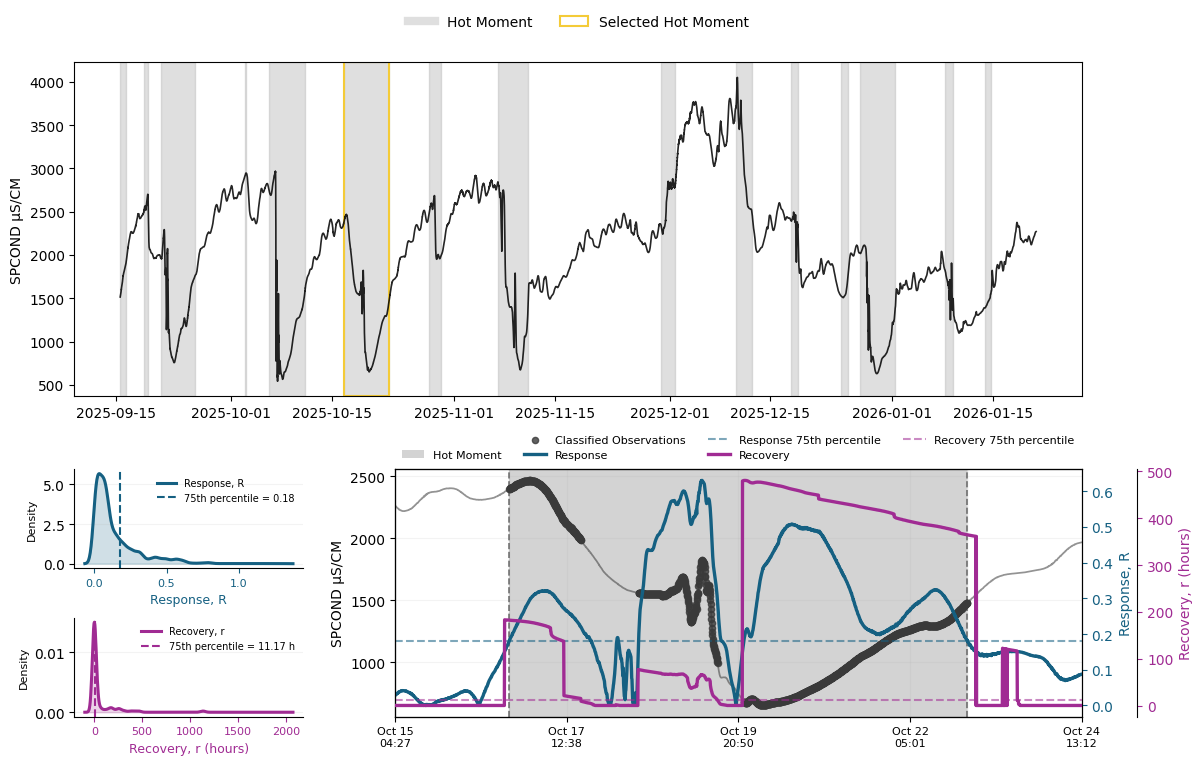

In [ ]:
# =========================================================
# Colors used in the plot
# =========================================================

signal_color = "#3A3A3A"
response_color = "#156082"
recovery_color = "#A02B93"

obs_edge_color = "#3A3A3A"

event_color = "#B0B0B0"
buffer_color = "#FFFFFF" # What is not a Hot moment


# =========================================================
# Clean time indexing
# =========================================================

for site in site_data:

    site_data[site].index = (
        site_data[site].index.tz_localize(None)
    )


results["start_time"] = pd.to_datetime(
    results["start_time"]
).dt.tz_localize(None)


# =========================================================
# Helper function:
# Compute Smooth Gaussian KDE using NumPy
# =========================================================

def smooth_density(values, n_points=500):

    values = np.asarray(values)

    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        return (
            np.array([]),
            np.array([])
        )

    # -----------------------------------------------------
    # Bandwidth
    # -----------------------------------------------------

    bandwidth = (
        1.06
        * np.std(values)
        * len(values) ** (-1 / 5)
    )

    # Prevent zero/invalid bandwidth
    if (
        bandwidth <= 0
        or not np.isfinite(bandwidth)
    ):
        bandwidth = 1.0


    # -----------------------------------------------------
    # X-axis
    # -----------------------------------------------------

    value_min = values.min()
    value_max = values.max()

    # Handle case where all values are identical
    if value_min == value_max:

        padding = max(
            abs(value_min) * 0.1,
            1.0
        )

        x = np.linspace(
            value_min - padding,
            value_max + padding,
            n_points
        )

    else:

        padding = (
            value_max - value_min
        ) * 0.05

        x = np.linspace(
            value_min - padding,
            value_max + padding,
            n_points
        )


    # -----------------------------------------------------
    # Gaussian kernels
    # -----------------------------------------------------

    kernels = np.exp(
        -0.5
        * (
            (x[:, None] - values[None, :])
            / bandwidth
        ) ** 2
    )


    # -----------------------------------------------------
    # Density
    # -----------------------------------------------------

    y = (
        kernels.sum(axis=1)
        / (
            len(values)
            * bandwidth
            * np.sqrt(2 * np.pi)
        )
    )


    return x, y


# =========================================================
# Loop structure
# =========================================================

for w in hot_moments.keys():

    df_window = results[
        results["window_length"] == w
    ]


    for site in hot_moments[w]:

        if site not in site_data:
            continue


        df_ts = site_data[site]


        df_site = df_window[
            df_window["site"] == site
        ]


        for parameter in hot_moments[w][site]:

            if parameter not in df_ts.columns:
                continue


            event_windows = (
                hot_moments[w][site][parameter]
            )


            df_param = df_site[
                df_site["parameter"] == parameter
            ]


            if len(event_windows) <= 5:
                continue


            # =================================================
            # Select event
            # =================================================

            event_start, event_end = (event_windows[5])
       
            # =================================================
            # Add buffer around event
            # =================================================

            event_duration = (event_end - event_start)

            buffer = (event_duration * 0.25)

            zoom_start = (event_start - buffer)

            zoom_end = (event_end + buffer)


            # =================================================
            # Data for zoomed panel
            # =================================================

            df_zoom = df_ts.loc[
                (df_ts.index >= zoom_start) &
                (df_ts.index <= zoom_end)
            ].copy()


            df_zoom_param = df_param[
                (df_param["start_time"] >= zoom_start) &
                (df_param["start_time"] <= zoom_end)
            ].copy()


            if (
                df_zoom.empty
                or df_zoom_param.empty
            ):
                continue


            # =================================================
            # Thresholds
            # =================================================

            R_thresh = (
                df_param["response_q3"]
                .iloc[0]
            )


            r_thresh = (
                df_param["recovery_q3"]
                .iloc[0]
            )


            # =================================================
            # Distribution data
            # =================================================

            # -------------------------------------------------
            # Response R
            # -------------------------------------------------

            R_clean = (
                df_param["response"]
                .dropna()
                .to_numpy()
            )

            R_clean = R_clean[
                np.isfinite(R_clean)
            ]


            # -------------------------------------------------
            # Recovery r
            # -------------------------------------------------

            r_clean = (
                df_param["recovery"]
                .dropna()
                .dt.total_seconds()
                .div(3600)
                .to_numpy()
            )

            r_clean = r_clean[
                np.isfinite(r_clean)
            ]


            # =================================================
            # Calculate smooth densities
            # =================================================

            R_x, R_density = (smooth_density(R_clean))
            r_x, r_density = (smooth_density(r_clean))
    

            # =================================================
            # Figure Sturcture
            #
            # Top:
            #   Full time series Plot
            #
            # Bottom-left:
            #   R density distribution Plot
            #   r density distribution Plot
            #
            # Bottom-right:
            #   zoomed/example hot moment Plot
            # =================================================

            fig = plt.figure(
                figsize=(13, 8.5)
            )


            gs = GridSpec(
                2,
                2,
                figure=fig,
                height_ratios=[
                    1.35,
                    1.0
                ],
                width_ratios=[
                    1.0,
                    3.0
                ],
                hspace=0.25,
                wspace=0.20
            )


            # -------------------------------------------------
            # Top (Full time series Plot)
            # -------------------------------------------------

            ax_full = fig.add_subplot(
                gs[0, :]
            )


            # -------------------------------------------------
            # Bottom-left (Density plots)
            # -------------------------------------------------

            gs_dist = gs[1, 0].subgridspec(
                2,
                1,
                hspace=0.5
            )


            ax_R_dist = fig.add_subplot(
                gs_dist[0, 0]
            )


            ax_r_dist = fig.add_subplot(
                gs_dist[1, 0]
            )


            # -------------------------------------------------
            # Bottom-right (Zoomed/Example hot moment Plot)
            # -------------------------------------------------

            ax_signal = fig.add_subplot(
                gs[1, 1]
            )


            # Response and recovery axes
            ax_R = ax_signal.twinx()

            ax_r = ax_signal.twinx()

            ax_r.spines[
                "right"
            ].set_position(
                ("outward", 40)
            )


            # =================================================
            #  Full time series Plot
            # =================================================

            ax_full.plot(
                df_ts.index,
                df_ts[parameter],
                color="black",
                linewidth=1.2,
                alpha=0.85
            )


            for s, e in event_windows:

                ax_full.axvspan(
                    s,
                    e,
                    color=event_color,
                    alpha=0.4
                )


            ax_full.plot(
                [],
                [],
                color=event_color,
                linewidth=6,
                alpha=0.4,
                label="Hot Moment"
            )


            ymin, ymax = (
                ax_full.get_ylim()
            )


            ax_full.add_patch(
                plt.Rectangle(
                    (
                        event_start,
                        ymin
                    ),
                    event_end - event_start,
                    ymax - ymin,
                    fill=False,
                    edgecolor="#F4CB38",
                    linewidth=1.5,
                    label="Selected Hot Moment"
                )
            )


            ax_full.set_ylabel(
                parameter
            )


            lines0, labels0 = (
                ax_full.get_legend_handles_labels()
            )


            ax_full.legend(
                lines0[:2],
                labels0[:2],
                frameon=False,
                loc="upper center",
                bbox_to_anchor=(
                    0.5,
                    1.18
                ),
                ncol=2
            )


            # =================================================
            #  Response, R density distribution Plot
            # =================================================

            if len(R_clean) > 0:

                ax_R_dist.fill_between(
                    R_x,
                    R_density,
                    color=response_color,
                    alpha=0.20
                )


                ax_R_dist.plot(
                    R_x,
                    R_density,
                    color=response_color,
                    linewidth=2.2
                )


                # 75th percentile
                ax_R_dist.axvline(
                    R_thresh,
                    color=response_color,
                    linestyle="--",
                    linewidth=1.5
                )


                # -------------------------------------------------
                # Legend
                # -------------------------------------------------

                ax_R_dist.plot(
                    [],
                    [],
                    color=response_color,
                    linewidth=2.2,
                    label="Response, R"
                )

                ax_R_dist.plot(
                    [],
                    [],
                    color=response_color,
                    linestyle="--",
                    linewidth=1.5,
                    label=f"75th percentile = {R_thresh:.2f}"
                )

                ax_R_dist.legend(
                    frameon=False,
                    fontsize=7,
                    loc="upper right"
                )


            ax_R_dist.set_xlabel(
                "Response, R",
                color=response_color,
                fontsize=9
            )


            ax_R_dist.set_ylabel(
                "Density",
                fontsize=8
            )


            ax_R_dist.tick_params(
                axis="x",
                colors=response_color,
                labelsize=8
            )


            ax_R_dist.grid(
                axis="y",
                alpha=0.15
            )


            ax_R_dist.spines[
                "top"
            ].set_visible(False)


            ax_R_dist.spines[
                "right"
            ].set_visible(False)


            # =================================================
            #  Recovery, r density distribution Plot
            # =================================================

            if len(r_clean) > 0:

                ax_r_dist.fill_between(
                    r_x,
                    r_density,
                    color=recovery_color,
                    alpha=0.20
                )

                ax_r_dist.plot(
                    r_x,
                    r_density,
                    color=recovery_color,
                    linewidth=2.2
                )

                # 75th percentile
                ax_r_dist.axvline(
                    r_thresh,
                    color=recovery_color,
                    linestyle="--",
                    linewidth=1.5
                )

                # -------------------------------------------------
                # Legend
                # -------------------------------------------------

                ax_r_dist.plot(
                    [],
                    [],
                    color=recovery_color,
                    linewidth=2.2,
                    label="Recovery, r"
                )


                ax_r_dist.plot(
                    [],
                    [],
                    color=recovery_color,
                    linestyle="--",
                    linewidth=1.5,
                    label=f"75th percentile = {r_thresh:.2f} h"
                )

                ax_r_dist.legend(
                    frameon=False,
                    fontsize=7,
                    loc="upper right"
                )


            ax_r_dist.set_xlabel(
                "Recovery, r (hours)",
                color=recovery_color,
                fontsize=9
            )


            ax_r_dist.set_ylabel("Density", fontsize=8)
          
            ax_r_dist.tick_params(
                axis="x",
                colors=recovery_color,
                labelsize=8
            )


            ax_r_dist.grid(axis="y", alpha=0.15)
        
            ax_r_dist.spines["top"].set_visible(False)
    
            ax_r_dist.spines["right"].set_visible(False)


            # =================================================
            # (C) Zoomed hot moment + buffer
            # =================================================

            # -------------------------------------------------
            # Background regions
            # -------------------------------------------------

            ax_signal.axvspan(
                zoom_start,
                event_start,
                color=buffer_color,
                alpha=0.35,
                zorder=0
            )


            ax_signal.axvspan(
                event_start,
                event_end,
                color=event_color,
                alpha=0.55,
                zorder=0
            )


            ax_signal.axvspan(
                event_end,
                zoom_end,
                color=buffer_color,
                alpha=0.35,
                zorder=0
            )


            # -------------------------------------------------
            # Event boundaries
            # -------------------------------------------------

            ax_signal.axvline(
                event_start,
                color="#555555",
                linestyle="--",
                linewidth=1.2,
                alpha=0.8
            )


            ax_signal.axvline(
                event_end,
                color="#555555",
                linestyle="--",
                linewidth=1.2,
                alpha=0.8
            )


            # -------------------------------------------------
            # Signal
            # -------------------------------------------------

            ax_signal.plot(
                df_zoom.index,
                df_zoom[parameter],
                color=signal_color,
                linewidth=1.25,
                alpha=0.55,
                zorder=2
            )


            # -------------------------------------------------
            # Response Timeseries
            # -------------------------------------------------

            ax_R.plot(
                df_zoom_param["start_time"],
                df_zoom_param["response"],
                color=response_color,
                linewidth=2.4,
                zorder=4,
                label="Response"
            )


            ax_R.axhline(
                R_thresh,
                color=response_color,
                linestyle="--",
                linewidth=1.5,
                alpha=0.55,
                label="Response 75th percentile"
            )


            # -------------------------------------------------
            # Recovery Timeseries
            # -------------------------------------------------

            ax_r.plot(
                df_zoom_param["start_time"],
                df_zoom_param["recovery"]
                .dt.total_seconds()
                .div(3600),
                color=recovery_color,
                linewidth=2.4,
                zorder=4,
                label="Recovery"
            )


            ax_r.axhline(
                r_thresh,
                color=recovery_color,
                linestyle="--",
                linewidth=1.5,
                alpha=0.55,
                label="Recovery 75th percentile"
            )


            # -------------------------------------------------
            # Classified Observations
            # -------------------------------------------------

            df_high = df_zoom_param[
                df_zoom_param["category"].isin(
                    [
                        "HighR_LongRec",
                        "HighR_NoRec"
                    ]
                )
            ]

            if not df_high.empty:

                ts_index = (df_zoom.index.to_numpy())
                
                ts_values = (df_zoom[parameter].to_numpy())

                event_times = (df_high["start_time"].to_numpy())

                idx = np.searchsorted(ts_index, event_times)

                idx = np.clip(idx, 0, len(ts_index) - 1)

                ax_signal.scatter(df_zoom.index[idx],
                    ts_values[idx],
                    s=20,
                    color=obs_edge_color,
                    alpha=0.8,
                    zorder=5,
                    label="Classified Observations"
                )


            # =================================================
            # Formatting: zoomed panel
            # =================================================

            ax_signal.set_xlim(zoom_start, zoom_end)
          
            ax_signal.set_ylabel(parameter)

            ax_R.set_ylabel("Response, R", color=response_color)

            ax_r.set_ylabel("Recovery, r (hours)", color=recovery_color)

            # -------------------------------------------------
            # Time axis
            # -------------------------------------------------

            num_ticks = 5

            tick_times = pd.date_range(start=zoom_start, end=zoom_end, periods=num_ticks)

            ax_signal.set_xticks(tick_times)

            ax_signal.xaxis.set_major_formatter(
                mdates.DateFormatter(
                    "%b %d\n%H:%M"
                )
            )

            ax_signal.tick_params(axis="x", labelrotation=0, labelsize=8)

            ax_signal.grid(alpha=0.15)

            ax_R.tick_params(axis="y", colors=response_color)

            ax_r.tick_params(axis="y", colors=recovery_color)


            # =================================================
            # Zoom-panel legend
            # =================================================

            legend_handles = [

                Patch(facecolor=buffer_color,alpha=0.35),

                Patch(facecolor=event_color, alpha=0.55, label="Hot Moment")
            ]


            lines1, labels1 = (ax_signal.get_legend_handles_labels())
            lines2, labels2 = (ax_R.get_legend_handles_labels())
            lines3, labels3 = (ax_r.get_legend_handles_labels())
    

            ax_signal.legend(legend_handles+ lines1 + lines2 + lines3,
                [
                    h.get_label()
                    for h in legend_handles
                ]
                + labels1 + labels2 + labels3,
                frameon=False,
                loc="upper center",
                bbox_to_anchor=(0.5, 1.18),
                ncol=4,
                fontsize=8
            )

            # =================================================
            # Final layout
            # =================================================

            plt.show()